In [208]:
# Feature engineering file

In [209]:
import sklearn
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import pandas as pd 



In [210]:
df = pd.read_csv("diabetes (1).csv")

In [211]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[20,30,40,50,60,80])

In [212]:
df['Glucose_BMI'] = df['Glucose']*df['BMI']



In [213]:
df['PregnancyGroup'] = pd.cut(
    df['Pregnancies'],
    bins=[-1,0,3,6,20],
    labels=['0','1-3','4-6','7+'])

In [214]:
y=df['Outcome']

X = df.drop(columns=['Outcome','AgeGroup','Glucose_BMI','PregnancyGroup']) 

num_features = X.select_dtypes(['int64','float64']).columns.tolist()

categorical_cols = X.select_dtypes(['category']).columns.tolist()



In [215]:
X_train,X_test,y_train ,y_test = train_test_split(X,y,test_size = 0.3,random_state=42)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [216]:
model = LogisticRegression()

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression())
])

pipeline.fit(X_train,y_train)




Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('model', LogisticRegression())])

In [217]:
y_pred = pipeline.predict(X_test)


In [218]:
from sklearn.metrics import recall_score, precision_score, accuracy_score

print(f'Recall score is {recall_score(y_test,y_pred)}')
print(f'Precision score is {precision_score(y_test,y_pred)}')
print(f'Accuracy score is {accuracy_score(y_test,y_pred)}')

Recall score is 0.625
Precision score is 0.6172839506172839
Accuracy score is 0.7359307359307359


The roc auc score is :  0.7980132450331127


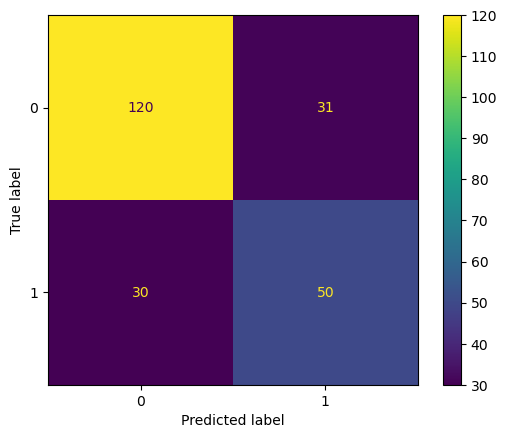

In [219]:
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import roc_auc_score

y_prob = pipeline.predict_proba(X_test)[:,1]

print("The roc auc score is : ",roc_auc_score(y_test, y_prob))

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)

In [220]:
X = df.drop(columns=['Outcome'])

num_features = X.select_dtypes(['int64','float64']).columns.tolist()

categorical_cols = X.select_dtypes(['category']).columns.tolist()



In [221]:


X_train,X_test,y_train ,y_test = train_test_split(X,y,test_size = 0.3,random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression())
])

In [222]:
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)


print(f'Recall score is {recall_score(y_test,y_pred)}')
print(f'Precision score is {precision_score(y_test,y_pred)}')
print(f'Accuracy score is {accuracy_score(y_test,y_pred)}')


Recall score is 0.625
Precision score is 0.6666666666666666
Accuracy score is 0.7619047619047619


The roc auc score is :  0.8000827814569537


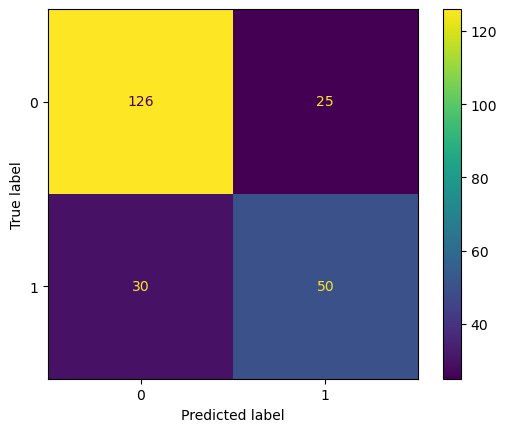

In [223]:
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)

y_prob = pipeline.predict_proba(X_test)[:,1]


print("The roc auc score is : ",roc_auc_score(y_test, y_prob))